# HR Attrition - Data Cleaning

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Data

In [3]:
df = pd.read_csv('HR_Attrition_UNCLEAN.csv')

## 3. Explore the Dataset

### 3.1 View First 5 Records

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,No,Travel_Rarely,642.0,Research & Development,1.0,3.0,Life Sciences,1.0,1999,...,1.0,80.0,1.0,12.0,3.0,3.0,5.0,3.0,1.0,0.0
1,36.0,no,Travel_Rarely,559.0,Research & Development,12.0,4.0,Life Sciences,1.0,1614,...,2.0,80.0,2.0,7.0,2.0,3.0,3.0,2.0,1.0,1.0
2,40.0,No,Travel_Rarely,1342.0,Sales,9.0,2.0,Medical,1.0,1548,...,4.0,80.0,0.0,9.0,5.0,4.0,8.0,4.0,7.0,1.0
3,52.0,Yes,Travel_Rarely,723.0,Research & Development,8.0,4.0,Medical,1.0,433,...,1.0,80.0,0.0,11.0,3.0,2.0,8.0,2.0,7.0,7.0
4,58.0,Yes,Travel_Frequently,781.0,Research & Development,2.0,1.0,Life Sciences,1.0,918,...,4.0,80.0,1.0,NaN,3.0,2.0,1.0,0.0,0.0,0.0


### 3.2 Dataset Info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2208 entries, 0 to 2207
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       2157 non-null   float64
 1   Attrition                 2200 non-null   object 
 2   BusinessTravel            2156 non-null   object 
 3   DailyRate                 2200 non-null   float64
 4   Department                2156 non-null   object 
 5   DistanceFromHome          2091 non-null   float64
 6   Education                 2200 non-null   float64
 7   EducationField            2167 non-null   object 
 8   EmployeeCount             2200 non-null   float64
 9   EmployeeNumber            2208 non-null   int64  
 10  EnvironmentSatisfaction   2068 non-null   float64
 11  Gender                    2178 non-null   object 
 12  HourlyRate                2200 non-null   float64
 13  JobInvolvement            2200 non-null   float64
 14  JobLevel

### 3.3 Statistical Summary

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2157.0,37.241076,10.550625,-5.0,30.00,36.0,43.00,150.0
DailyRate,2200.0,801.307727,404.786017,102.0,465.75,802.0,1153.00,1499.0
DistanceFromHome,2091.0,9.246294,8.168505,0.0,2.00,7.0,14.00,32.0
Education,2200.0,2.905000,1.017166,1.0,2.00,3.0,4.00,5.0
EmployeeCount,2200.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,2208.0,1449.944746,811.873404,1.0,728.75,1498.0,2191.25,2718.0
EnvironmentSatisfaction,2068.0,2.709865,1.098426,1.0,2.00,3.0,4.00,4.0
HourlyRate,2200.0,65.955909,20.237704,27.0,48.00,66.0,83.00,103.0
JobInvolvement,2200.0,2.722273,0.708972,1.0,2.00,3.0,3.00,4.0
JobLevel,2200.0,2.066818,1.097183,1.0,1.00,2.0,3.00,5.0


### 3.4 Dataset Shape

In [7]:
df.shape

(2208, 35)

## 4. Checking Missing Values

In [8]:
df.isna().sum()

Age                          51
Attrition                     8
BusinessTravel               52
DailyRate                     8
Department                   52
DistanceFromHome            117
Education                     8
EducationField               41
EmployeeCount                 8
EmployeeNumber                0
EnvironmentSatisfaction     140
Gender                       30
HourlyRate                    8
JobInvolvement                8
JobLevel                      8
JobRole                       8
JobSatisfaction             117
MaritalStatus                 8
MonthlyIncome                96
MonthlyRate                   8
NumCompaniesWorked          118
Over18                        8
OverTime                      8
PercentSalaryHike             8
PerformanceRating             8
RelationshipSatisfaction      8
StandardHours                 8
StockOptionLevel              8
TotalWorkingYears            73
TrainingTimesLastYear         8
WorkLifeBalance              96
YearsAtC

### 4.1 Checking Missing Values Percentage

In [9]:
(df.isnull().sum()/len(df))*100

Age                         2.309783
Attrition                   0.362319
BusinessTravel              2.355072
DailyRate                   0.362319
Department                  2.355072
DistanceFromHome            5.298913
Education                   0.362319
EducationField              1.856884
EmployeeCount               0.362319
EmployeeNumber              0.000000
EnvironmentSatisfaction     6.340580
Gender                      1.358696
HourlyRate                  0.362319
JobInvolvement              0.362319
JobLevel                    0.362319
JobRole                     0.362319
JobSatisfaction             5.298913
MaritalStatus               0.362319
MonthlyIncome               4.347826
MonthlyRate                 0.362319
NumCompaniesWorked          5.344203
Over18                      0.362319
OverTime                    0.362319
PercentSalaryHike           0.362319
PerformanceRating           0.362319
RelationshipSatisfaction    0.362319
StandardHours               0.362319
S

## 5. Dropping Fully-Empty/Junk Rows

In [10]:
threshold = int(df.shape[1] * 0.5)
df = df.dropna(thresh=threshold)   # thresh = kam se kam kitne non-null values chahiye
print("Shape after dropping junk rows:", df.shape)

Shape after dropping junk rows: (2200, 35)


## 6. Checking and Removing Duplicate Records

### 6.1 Check Duplicate 

In [11]:
df.duplicated().sum()

np.int64(15)

### 6.2 Remove Duplicate Records

In [12]:
df=df.drop_duplicates()

In [13]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,No,Travel_Rarely,642.0,Research & Development,1.0,3.0,Life Sciences,1.0,1999,...,1.0,80.0,1.0,12.0,3.0,3.0,5.0,3.0,1.0,0.0
1,36.0,no,Travel_Rarely,559.0,Research & Development,12.0,4.0,Life Sciences,1.0,1614,...,2.0,80.0,2.0,7.0,2.0,3.0,3.0,2.0,1.0,1.0
2,40.0,No,Travel_Rarely,1342.0,Sales,9.0,2.0,Medical,1.0,1548,...,4.0,80.0,0.0,9.0,5.0,4.0,8.0,4.0,7.0,1.0
3,52.0,Yes,Travel_Rarely,723.0,Research & Development,8.0,4.0,Medical,1.0,433,...,1.0,80.0,0.0,11.0,3.0,2.0,8.0,2.0,7.0,7.0
4,58.0,Yes,Travel_Frequently,781.0,Research & Development,2.0,1.0,Life Sciences,1.0,918,...,4.0,80.0,1.0,NaN,3.0,2.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2203,44.0,Yes,Travel_Rarely,1376.0,Human Resources,1.0,2.0,Medical,1.0,1098,...,4.0,80.0,1.0,24.0,1.0,3.0,20.0,6.0,3.0,6.0
2204,36.0,No,Travel_Frequently,607.0,Sales,7.0,3.0,Marketing,1.0,1362,...,4.0,80.0,1.0,17.0,2.0,2.0,15.0,7.0,6.0,13.0
2205,28.0,No,Non-Travel,990.0,Research & Development,9.0,3.0,Technical Degree,1.0,2266,...,2.0,80.0,2.0,0.0,2.0,2.0,1.0,0.0,0.0,0.0
2206,19.0,Yes,Travel_Rarely,614.0,Research & Development,4.0,1.0,Life Sciences,1.0,2287,...,1.0,80.0,1.0,6.0,3.0,4.0,6.0,2.0,0.0,2.0


In [14]:
df = df.drop_duplicates(subset='EmployeeNumber',keep='first').copy()

In [15]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,No,Travel_Rarely,642.0,Research & Development,1.0,3.0,Life Sciences,1.0,1999,...,1.0,80.0,1.0,12.0,3.0,3.0,5.0,3.0,1.0,0.0
1,36.0,no,Travel_Rarely,559.0,Research & Development,12.0,4.0,Life Sciences,1.0,1614,...,2.0,80.0,2.0,7.0,2.0,3.0,3.0,2.0,1.0,1.0
2,40.0,No,Travel_Rarely,1342.0,Sales,9.0,2.0,Medical,1.0,1548,...,4.0,80.0,0.0,9.0,5.0,4.0,8.0,4.0,7.0,1.0
3,52.0,Yes,Travel_Rarely,723.0,Research & Development,8.0,4.0,Medical,1.0,433,...,1.0,80.0,0.0,11.0,3.0,2.0,8.0,2.0,7.0,7.0
4,58.0,Yes,Travel_Frequently,781.0,Research & Development,2.0,1.0,Life Sciences,1.0,918,...,4.0,80.0,1.0,NaN,3.0,2.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2203,44.0,Yes,Travel_Rarely,1376.0,Human Resources,1.0,2.0,Medical,1.0,1098,...,4.0,80.0,1.0,24.0,1.0,3.0,20.0,6.0,3.0,6.0
2204,36.0,No,Travel_Frequently,607.0,Sales,7.0,3.0,Marketing,1.0,1362,...,4.0,80.0,1.0,17.0,2.0,2.0,15.0,7.0,6.0,13.0
2205,28.0,No,Non-Travel,990.0,Research & Development,9.0,3.0,Technical Degree,1.0,2266,...,2.0,80.0,2.0,0.0,2.0,2.0,1.0,0.0,0.0,0.0
2206,19.0,Yes,Travel_Rarely,614.0,Research & Development,4.0,1.0,Life Sciences,1.0,2287,...,1.0,80.0,1.0,6.0,3.0,4.0,6.0,2.0,0.0,2.0


## 7. Cleaning Text Clolumns


In [16]:
text_cols = df.select_dtypes(include='object').columns
text_cols

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [17]:
for i in ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus', 'OverTime']:
    df[i]=df[i].str.strip()
    df[i]=df[i].str.title()

In [18]:
df['Gender'] = df.Gender.str.strip().str.lower()
df['Gender'] = df.Gender.replace({'male':'Male', 'm':'Male', 'female':'Female', 'f':'Female'})

In [19]:
df.Gender.unique()

array(['Male', 'Female', nan], dtype=object)

## 8.Fixing Outliers/Invalid Values


In [20]:
df.loc[(df.Age<18) | (df.Age>60), 'Age'] = np.nan

## 9. Outlier Detection using Boxplot

In [21]:
count_df= df.select_dtypes(include='number').columns
count_df

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

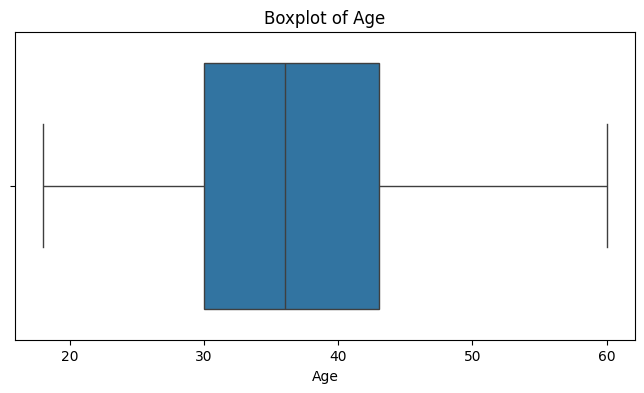

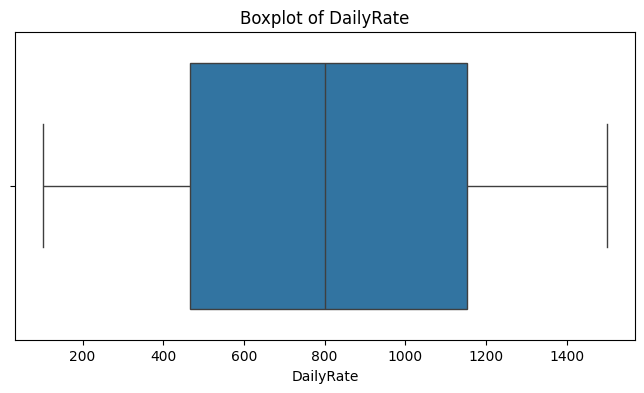

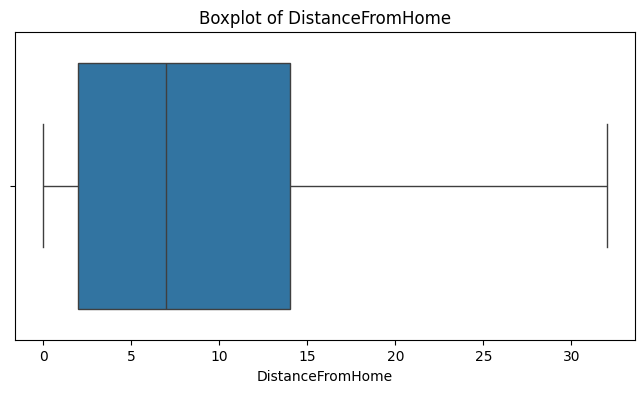

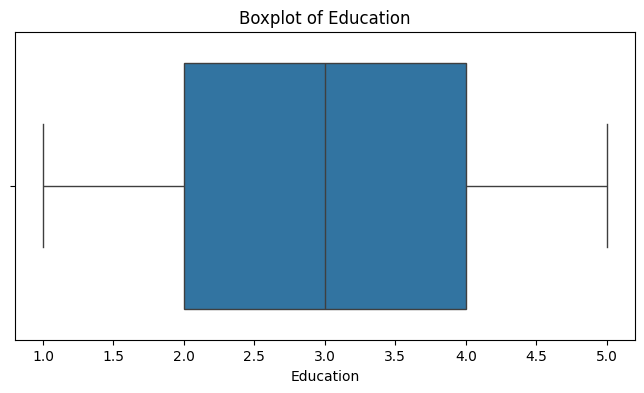

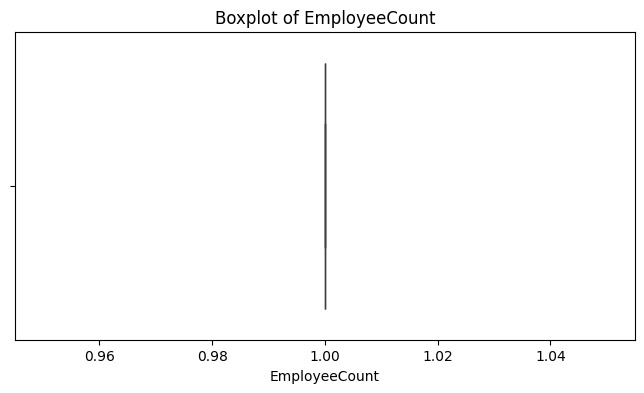

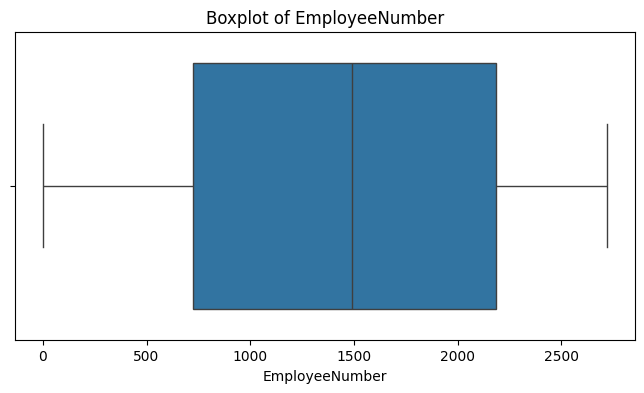

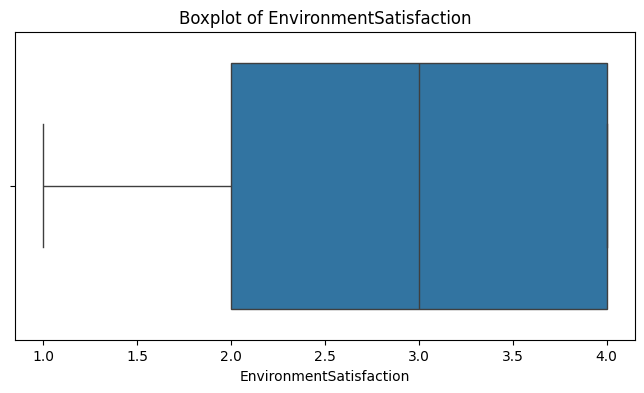

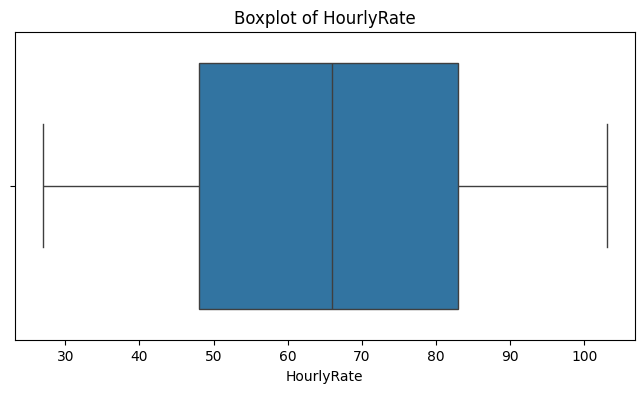

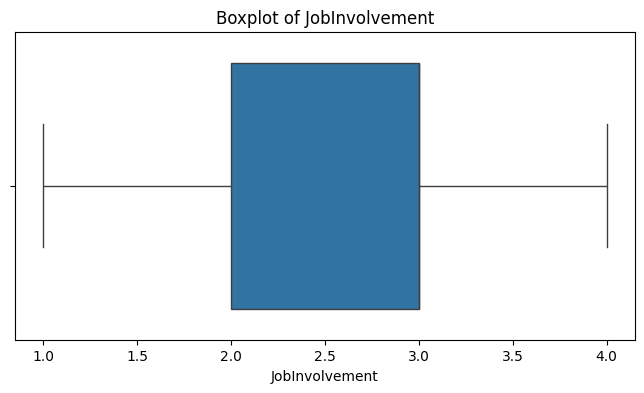

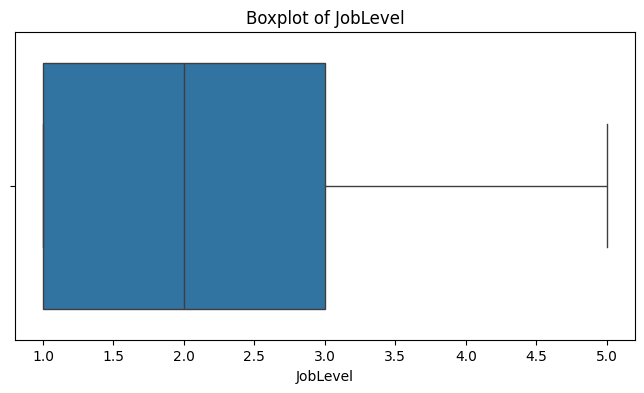

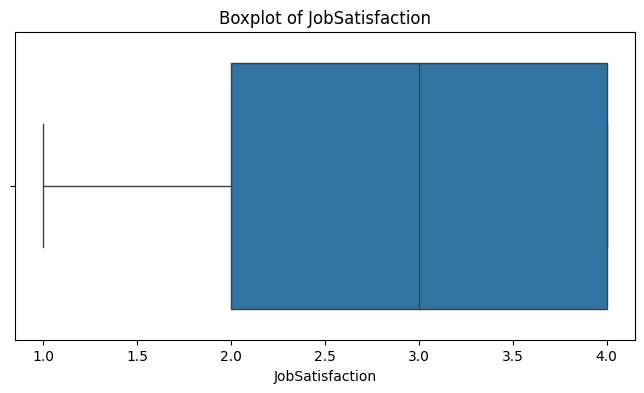

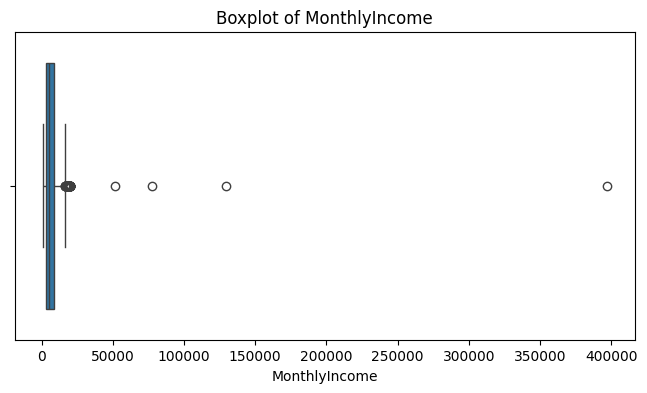

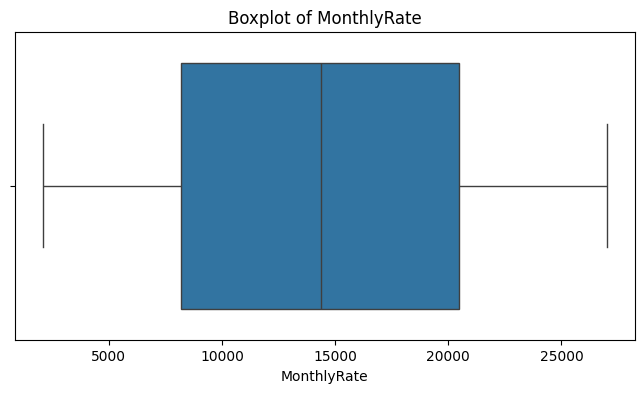

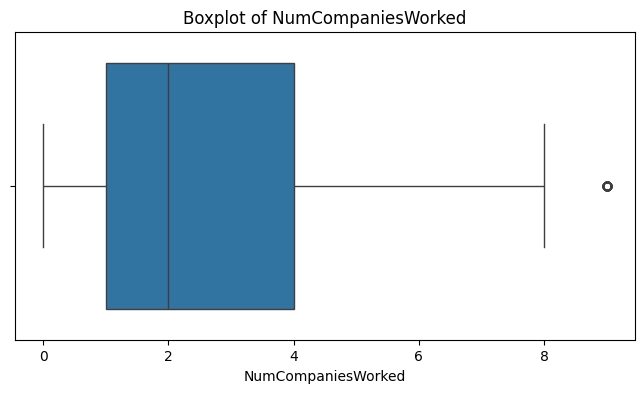

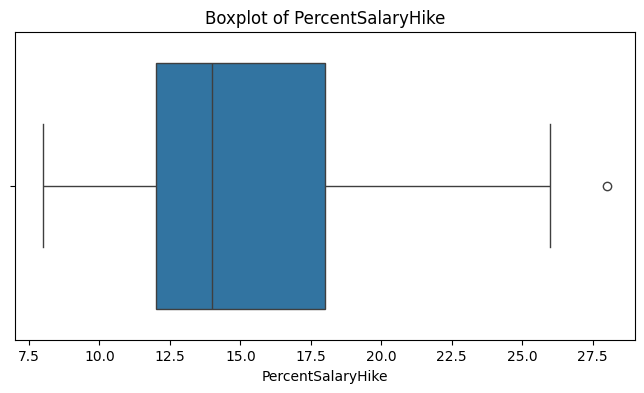

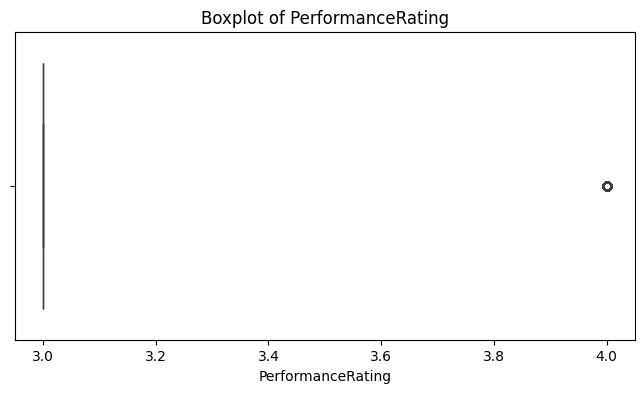

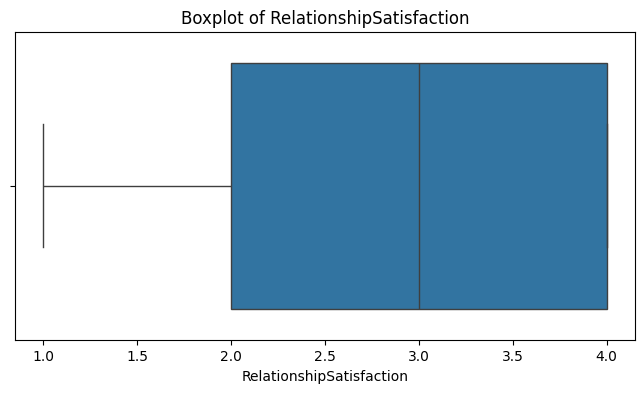

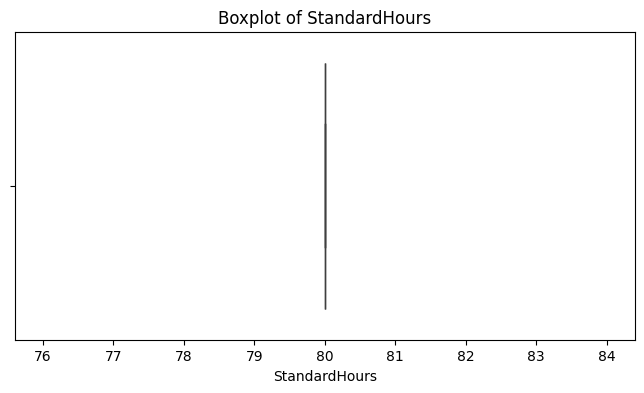

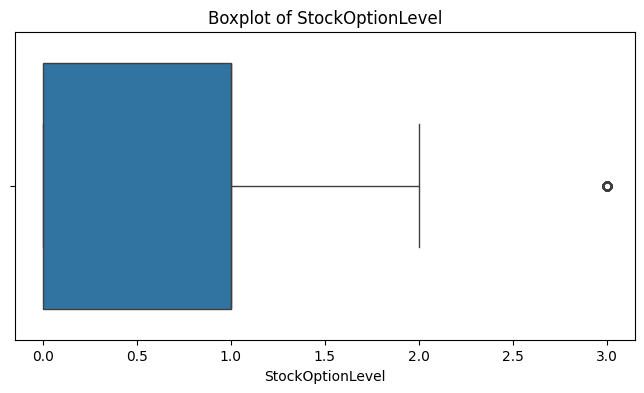

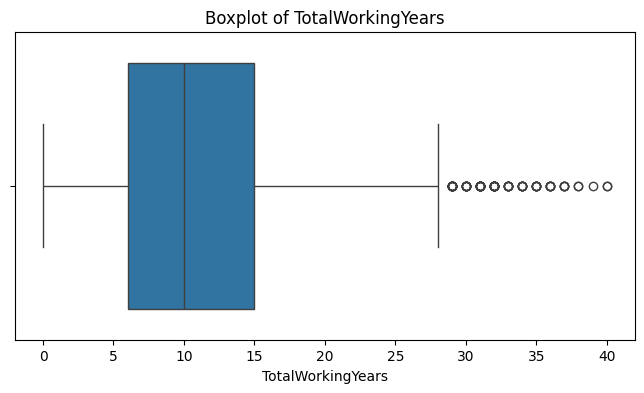

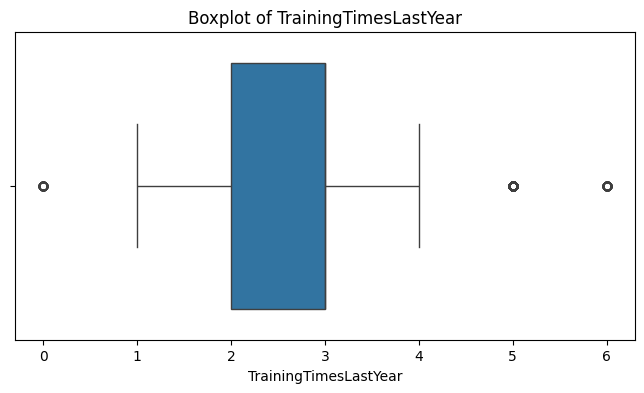

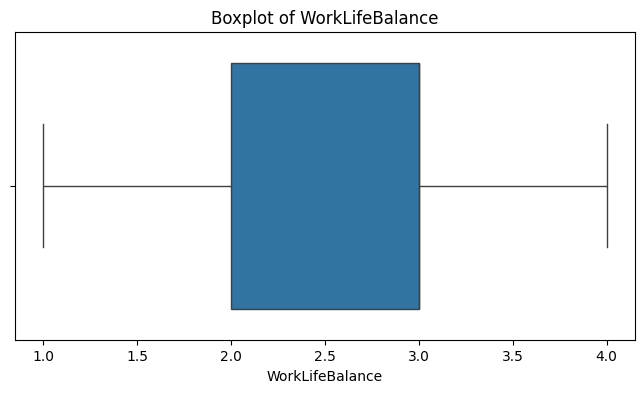

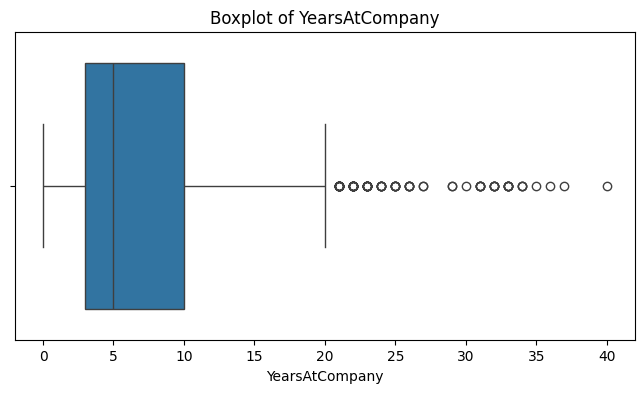

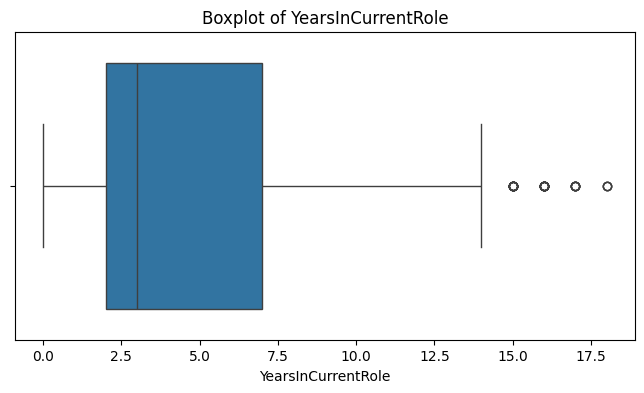

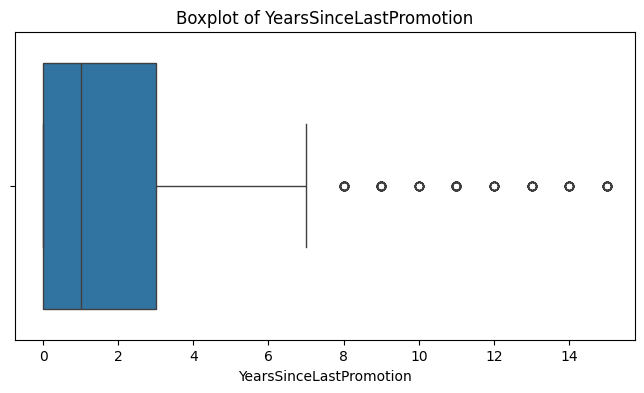

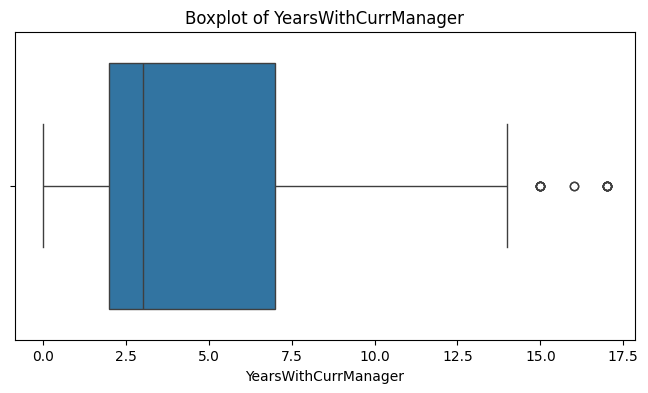

In [22]:
for i in count_df:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[i])
    plt.title(f'Boxplot of {i}')
    plt.xlabel(i)
    plt.show()
  

## 9.1 Outlier Detection using IQR

In [23]:
for i in count_df:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[i] < lower) | 
        (df[i] > upper)
    ]

    print(f"{i}: {len(outliers)} outliers")

Age: 0 outliers
DailyRate: 0 outliers
DistanceFromHome: 0 outliers
Education: 0 outliers
EmployeeCount: 0 outliers
EmployeeNumber: 0 outliers
EnvironmentSatisfaction: 0 outliers
HourlyRate: 0 outliers
JobInvolvement: 0 outliers
JobLevel: 0 outliers
JobSatisfaction: 0 outliers
MonthlyIncome: 147 outliers
MonthlyRate: 0 outliers
NumCompaniesWorked: 72 outliers
PercentSalaryHike: 1 outliers
PerformanceRating: 327 outliers
RelationshipSatisfaction: 0 outliers
StandardHours: 0 outliers
StockOptionLevel: 117 outliers
TotalWorkingYears: 86 outliers
TrainingTimesLastYear: 337 outliers
WorkLifeBalance: 0 outliers
YearsAtCompany: 93 outliers
YearsInCurrentRole: 33 outliers
YearsSinceLastPromotion: 147 outliers
YearsWithCurrManager: 17 outliers


In [24]:
for i in ['NumCompaniesWorked','PerformanceRating','StockOptionLevel','TotalWorkingYears','YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']:
    print(df[i].value_counts())
    print('\n')


NumCompaniesWorked
1.0    696
0.0    283
3.0    212
2.0    194
4.0    192
7.0    110
5.0     96
6.0     90
9.0     72
8.0     61
Name: count, dtype: int64


PerformanceRating
3.0    1787
4.0     327
Name: count, dtype: int64


StockOptionLevel
0.0    905
1.0    867
2.0    225
3.0    117
Name: count, dtype: int64


TotalWorkingYears
10.0    230
6.0     154
8.0     146
9.0     135
7.0     129
5.0     114
1.0      97
4.0      89
12.0     83
3.0      70
11.0     62
13.0     59
2.0      54
15.0     53
14.0     52
18.0     46
16.0     43
21.0     42
17.0     41
20.0     38
0.0      34
19.0     33
23.0     32
22.0     29
24.0     24
26.0     22
25.0     22
28.0     19
29.0     16
31.0     16
32.0     14
27.0     13
30.0      8
33.0      6
35.0      6
34.0      6
36.0      5
37.0      4
40.0      2
38.0      2
39.0      1
Name: count, dtype: int64


YearsAtCompany
5.0     236
1.0     208
3.0     180
2.0     176
4.0     169
10.0    151
7.0     125
8.0     121
6.0     117
0.0     109
9.0     108

## 9.2 Outlier Summary & Decisions
### MonthlyIncome: Extreme values were capped using the IQR method.
### Age: Invalid values below 18 or above 60 were treated as missing and filled with the median.
### Other columns: IQR identified some potential outliers in fields such as PerformanceRating and YearsAtCompany. These were reviewed and kept because they represent valid business variation, such as senior employees and high performers.

## 10. Fixing Outliers

## MonthlyIncome (upper outlier) Cap-> IQR method 

In [25]:
Q1 = df.MonthlyIncome.quantile(0.25)
Q3 = df.MonthlyIncome.quantile(0.75)
IQR = Q3 - Q1
ur = Q3 + 1.5 * IQR
df['MonthlyIncome'] = df.MonthlyIncome.clip(upper= ur)

## 10.1 Checking it by creating Boxplot

<Axes: xlabel='MonthlyIncome'>

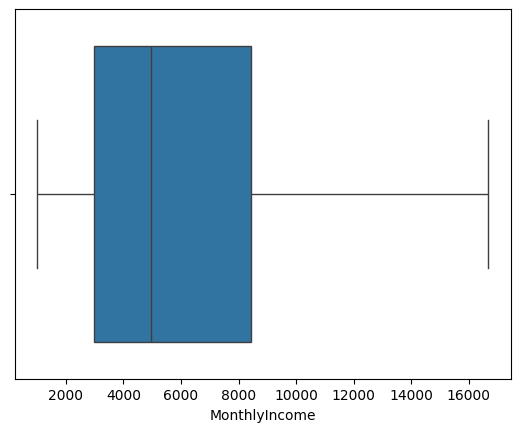

In [26]:
sns.boxplot(data= df, x='MonthlyIncome')

## 10.2 Check it 

In [27]:
for i in count_df:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[i] < lower) | 
        (df[i] > upper)
    ]

    print(f"{i}: {len(outliers)} outliers")

Age: 0 outliers
DailyRate: 0 outliers
DistanceFromHome: 0 outliers
Education: 0 outliers
EmployeeCount: 0 outliers
EmployeeNumber: 0 outliers
EnvironmentSatisfaction: 0 outliers
HourlyRate: 0 outliers
JobInvolvement: 0 outliers
JobLevel: 0 outliers
JobSatisfaction: 0 outliers
MonthlyIncome: 0 outliers
MonthlyRate: 0 outliers
NumCompaniesWorked: 72 outliers
PercentSalaryHike: 1 outliers
PerformanceRating: 327 outliers
RelationshipSatisfaction: 0 outliers
StandardHours: 0 outliers
StockOptionLevel: 117 outliers
TotalWorkingYears: 86 outliers
TrainingTimesLastYear: 337 outliers
WorkLifeBalance: 0 outliers
YearsAtCompany: 93 outliers
YearsInCurrentRole: 33 outliers
YearsSinceLastPromotion: 147 outliers
YearsWithCurrManager: 17 outliers


## 11. Handling Missing Values
### Numeric columns -> filling by median  
### Categorical cols -> filling by mode 

In [28]:
count_df = df.select_dtypes(include='number').columns

for i in count_df:
    df[i] = df[i].fillna(df[i].median())

In [29]:
cat_df = df.select_dtypes(include='object').columns

for i in cat_df:
    df[i] = df[i].fillna(df[i].mode()[0])

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2114 entries, 0 to 2207
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       2114 non-null   float64
 1   Attrition                 2114 non-null   object 
 2   BusinessTravel            2114 non-null   object 
 3   DailyRate                 2114 non-null   float64
 4   Department                2114 non-null   object 
 5   DistanceFromHome          2114 non-null   float64
 6   Education                 2114 non-null   float64
 7   EducationField            2114 non-null   object 
 8   EmployeeCount             2114 non-null   float64
 9   EmployeeNumber            2114 non-null   int64  
 10  EnvironmentSatisfaction   2114 non-null   float64
 11  Gender                    2114 non-null   object 
 12  HourlyRate                2114 non-null   float64
 13  JobInvolvement            2114 non-null   float64
 14  JobLevel     

## 12. Data Type Conversion
### Converted relevant numeric columns to integer data type after handling missing values.

In [31]:
flt_col = ["Age","DistanceFromHome", "EnvironmentSatisfaction",
                  "JobSatisfaction", "WorkLifeBalance", "TotalWorkingYears",
                  "NumCompaniesWorked", "YearsAtCompany", "TrainingTimesLastYear"]
for i in flt_col:
    df[i] = df[i].astype(int)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2114 entries, 0 to 2207
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       2114 non-null   int64  
 1   Attrition                 2114 non-null   object 
 2   BusinessTravel            2114 non-null   object 
 3   DailyRate                 2114 non-null   float64
 4   Department                2114 non-null   object 
 5   DistanceFromHome          2114 non-null   int64  
 6   Education                 2114 non-null   float64
 7   EducationField            2114 non-null   object 
 8   EmployeeCount             2114 non-null   float64
 9   EmployeeNumber            2114 non-null   int64  
 10  EnvironmentSatisfaction   2114 non-null   int64  
 11  Gender                    2114 non-null   object 
 12  HourlyRate                2114 non-null   float64
 13  JobInvolvement            2114 non-null   float64
 14  JobLevel     

## 13. Dropping Constant/Useless Columns

In [33]:
df.drop(columns=['EmployeeCount','Over18','StandardHours'],inplace=True)

In [34]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,No,Travel_Rarely,642.0,Research & Development,1,3.0,Life Sciences,1999,4,...,4.0,1.0,1.0,12,3,3,5,3.0,1.0,0.0
1,36,No,Travel_Rarely,559.0,Research & Development,12,4.0,Life Sciences,1614,3,...,3.0,2.0,2.0,7,2,3,3,2.0,1.0,1.0
2,40,No,Travel_Rarely,1342.0,Sales,9,2.0,Medical,1548,1,...,3.0,4.0,0.0,9,5,4,8,4.0,7.0,1.0
3,52,Yes,Travel_Rarely,723.0,Research & Development,8,4.0,Medical,433,3,...,3.0,1.0,0.0,11,3,2,8,2.0,7.0,7.0
4,58,Yes,Travel_Frequently,781.0,Research & Development,2,1.0,Life Sciences,918,4,...,3.0,4.0,1.0,10,3,2,1,0.0,0.0,0.0


## 14. Exporting  the Cleaned Dataset

In [35]:
df.to_csv("HR_Attrition_CLEANED.csv", index=False)

print("Final shape:", df.shape)

Final shape: (2114, 32)


## 15.Final validation

In [36]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Age range:", df.Age.min(), "-", df.Age.max())
print("Final shape:", df.shape)

Missing values: 0
Duplicate rows: 0
Age range: 18 - 60
Final shape: (2114, 32)


## 16. Load Cleaned Data into SQL Server (SSMS)

In [37]:
pip install sqlalchemy pyodbc 

Note: you may need to restart the kernel to use updated packages.


In [38]:
import pandas as pd
from sqlalchemy import create_engine

In [39]:
# loading csv file
df = pd.read_csv('HR_Attrition_CLEANED.csv')
print('Shape:', df.shape)

Shape: (2114, 32)


In [40]:
# SQL Server details
server='.\SQLEXPRESS'
database='HR_Project'
driver='ODBC Driver 18 for SQL Server'

In [41]:
# Connecting From SQL Server
engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}?driver={driver}&trusted_connection=yes&TrustServerCertificate=yes"
)

In [42]:
# STEP 5: Putting DataFrame into SQL table 

df.to_sql(
    name="hr_attrition",   
    con=engine,
    if_exists="replace",    
    index=False              
)

print(" Data successfully loaded into SQL Server!")

 Data successfully loaded into SQL Server!
